# cVAE (MLP) on the Global + Local Family Dataset

This notebook is written as a guided walkthrough for first-time learners who want to move from forward prediction into **inverse design**. Instead of learning only a one-way mapping from design variables to response, you will train a **conditional variational autoencoder (cVAE)** that learns a distribution over valid local modification grids. The model will see a condition vector describing the global family context and the desired structural response, then learn how to generate plausible local `n x n` grids that satisfy that condition.

The dataset is assumed to have been collected using `sampler_globalLocalFamilyGrid.py` and `logger_globalLocalFamily.py` scripts. Each CSV row stores one global shell, one flattened local grid in row-major order, and scalar analysis outputs such as `max_disp`.

By the end of the notebook, you should be able to inspect this family-structured dataset, prepare leakage-safe condition and local inputs, train a compact MLP-based cVAE, evaluate reconstructions, visualize latent behavior, and save the pieces needed for later generative inference.

## 1. Imports + Reproducibility Seed

Before touching the dataset, we set up the environment so the notebook behaves predictably. Reproducibility matters in generative workflows too: random train/validation/test splits, latent sampling, and random weight initialization can all move the final behavior enough to make it hard to evaluate between training runs. Fixing the seed makes comparisons easier to trust and makes it much easier to tell the difference between a modeling change and simple random variation.

The toolchain stays close to the other teaching notebooks: `pandas` for tabular inspection, `matplotlib/seaborn` for visualization, `scikit-learn` for splitting, scaling, and geometry projections, and `keras` for the neural network. This setup cell keeps only the universal environment choices such as imports, the seed, and TensorFlow logging behavior.

In [1]:
from pathlib import Path
import json
import os
import pickle
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
try:
    from sklearn.metrics import mean_absolute_error, root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
from tensorflow import keras
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel("ERROR")
sns.set_theme(style="whitegrid")
print(f"Seed fixed to {SEED} for Python, NumPy, and TensorFlow.")
print("TensorFlow logger set to ERROR to hide backend deprecation noise during training.")

Seed fixed to 42 for Python, NumPy, and TensorFlow.
TensorFlow logger set to ERROR to hide backend deprecation noise during training.


## 2. Load Dataset

This section mirrors the organizational pattern used in the regression and classification notebooks: dataset-specific choices live here, close to the data loading code. That means the path logic, CSV filename candidates, and target column are all declared in the same block rather than being scattered across the notebook.

Each row of this dataset should represent one sampled family case. We expect bookkeeping columns such as `sample_id`, a set of global-family scalar parameters, a flattened local `n x n` grid with names like `l_r00_c00`, and the response target `max_disp`. If `max_disp_baseline` exists, we will keep it as an optional conditioning feature because it can be useful for inverse design without changing the core dataset contract.

The load cell also performs a practical path check so the notebook works whether your kernel starts from the repo root or from `inclass_examples/notebooks/`.

In [2]:
if Path("inclass_examples").exists():
    DATA_DIR = Path("inclass_examples/data/scalar")
else:
    DATA_DIR = Path("../data/scalar")
csv_candidates = [
    DATA_DIR / "global_local_family.csv",
    DATA_DIR / "globalLocal_features_dataset.csv",
]
target_col = "max_disp"
CSV_PATH = next((path for path in csv_candidates if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "Could not find a global/local family CSV. Export a dataset with logger_globalLocalFamily.py "
        "into inclass_examples/data/scalar/ first."
    )
df = pd.read_csv(CSV_PATH)
required_cols = {"sample_id", "global_family_id", "local_variant_id", target_col}
missing_required = required_cols.difference(df.columns)
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_required)}")
df["local_variant_id"] = pd.to_numeric(df["local_variant_id"], errors="raise").astype(int)
df["is_baseline"] = df["local_variant_id"].eq(-1)
local_pattern = re.compile(r"^l_r(\d+)_c(\d+)$")
local_matches = []
for col in df.columns:
    match = local_pattern.match(col)
    if match:
        local_matches.append((int(match.group(1)), int(match.group(2)), col))
if not local_matches:
    raise ValueError("No local grid columns found. Expected names like l_r00_c00.")
local_matches.sort()
local_cols = [col for _, _, col in local_matches]
row_ids = sorted({row for row, _, _ in local_matches})
col_ids = sorted({col for _, col, _ in local_matches})
inferred_grid_n = len(row_ids)
if inferred_grid_n != len(col_ids) or inferred_grid_n * inferred_grid_n != len(local_cols):
    raise ValueError("Local grid columns do not form a complete square n x n layout.")
grid_n = inferred_grid_n
meta_cols = {
    "sample_id", "global_family_id", "local_variant_id", "is_baseline", "local_grid_n", "local_grid_order",
    "valid_geometry", "valid_analysis", "failure_reason", "max_disp_baseline", "max_disp_delta",
}
global_cols = [col for col in df.columns if col not in meta_cols and col not in local_cols and col != target_col]
condition_cols = list(global_cols)
if "max_disp_baseline" in df.columns and df["max_disp_baseline"].notna().any():
    condition_cols.append("max_disp_baseline")
condition_cols.append(target_col)
baseline_rows = int(df["is_baseline"].sum())
variant_rows = int((~df["is_baseline"]).sum())
print(f"Loaded file: {CSV_PATH.resolve()}")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Rows: {len(df):,} | Global columns: {len(global_cols)} | Local cells: {len(local_cols)} ({grid_n}x{grid_n})")
print(f"Target column: {target_col}")
print(f"Baseline rows: {baseline_rows:,} | Variant rows: {variant_rows:,}")
print(f"Condition columns: {condition_cols}")
print()
print("First 5 rows:")
display(df.head())

Loaded file: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\data\scalar\globalLocal_features_dataset.csv
Data directory: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\data\scalar
Rows: 32,768 | Global columns: 3 | Local cells: 25 (5x5)
Target column: max_disp
Baseline rows: 256 | Variant rows: 32,512
Condition columns: ['g_00', 'g_01', 'g_02', 'max_disp_baseline', 'max_disp']

First 5 rows:


,sample_id,global_family_id,local_variant_id,g_00,g_01,g_02,l_r00_c00,l_r00_c01,l_r00_c02,l_r00_c03,...,l_r03_c04,l_r04_c00,l_r04_c01,l_r04_c02,l_r04_c03,l_r04_c04,max_disp,max_disp_baseline,max_disp_delta,is_baseline
0,0,0,-1,9.591402,0.375161,-2.249707,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,136.777097,136.777097,0.000000,True
1,1,0,0,9.591402,0.375161,-2.249707,-0.461448,0.196224,-0.356067,-0.037468,...,-0.404257,0.012430,-0.004023,0.272301,0.097217,0.006676,109.702574,136.777097,-27.074523,False
2,2,0,1,9.591402,0.375161,-2.249707,0.075159,-0.123075,-0.451080,-0.438789,...,0.028891,0.201155,-0.333182,0.348360,0.280865,-0.449903,94.706788,136.777097,-42.070309,False
3,3,0,2,9.591402,0.375161,-2.249707,0.091408,-0.131948,-0.313992,0.104480,...,0.307469,-0.391059,0.035189,-0.056923,-0.462026,-0.497481,103.703503,136.777097,-33.073594,False
4,4,0,3,9.591402,0.375161,-2.249707,0.403530,0.476608,-0.375680,0.234591,...,-0.095340,0.185047,0.075631,-0.239679,0.086324,0.412454,99.349394,136.777097,-37.427703,False


## 3. Data Quality Check

A generative model is only as useful as the design manifold it sees during training. That is why this section does more than a minimal null-check. We look for missing values, infinite values, duplicate identifiers, duplicate rows, and any signs that the local grid export is incomplete or inconsistent. These are exactly the kinds of quiet data issues that can make a cVAE look unstable even when the model code is fine.

For this dataset, baseline rows are inferred directly from `local_variant_id == -1`, and the current `logger_globalLocalFamily.py` writes only successful analysis rows. In other words, this section is less about filtering failed simulations and more about verifying that the CSV is internally coherent before we ask a generative model to learn from it.

In [3]:
rows_before_cleaning = len(df)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    infinite_counts = pd.Series(np.isinf(df[numeric_cols].to_numpy()).sum(axis=0), index=numeric_cols).sort_values(ascending=False)
else:
    infinite_counts = pd.Series(dtype="int64")
infinite_total = int(infinite_counts.sum()) if not infinite_counts.empty else 0
if infinite_total > 0:
    df = df.replace([np.inf, -np.inf], np.nan)

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_total = int(missing_counts.sum())
rows_with_missing = int(df.isna().any(axis=1).sum())

duplicate_sample_ids = int(df["sample_id"].duplicated().sum())
duplicate_rows = int(df.duplicated().sum())
baseline_rows_before_cleaning = int(df["is_baseline"].sum())
variant_rows_before_cleaning = int((~df["is_baseline"]).sum())

rows_before_target_drop = len(df)
df = df.dropna(subset=condition_cols + local_cols).copy()
dropped_missing_rows = rows_before_target_drop - len(df)

rows_before_duplicate_drop = len(df)
df = df.drop_duplicates(subset=["sample_id"]).reset_index(drop=True)
dropped_duplicate_rows = rows_before_duplicate_drop - len(df)

local_value_range = (float(df[local_cols].min().min()), float(df[local_cols].max().max())) if len(df) > 0 else (float("nan"), float("nan"))
max_disp_summary = df["max_disp"].describe() if len(df) > 0 else pd.Series(dtype="float64")

print(f"Rows before cleaning: {rows_before_cleaning}")
print(f"Rows with at least one missing value: {rows_with_missing}")
print(f"Total missing values after inf-to-NaN conversion: {missing_total}")
if missing_total > 0:
    display(missing_counts[missing_counts > 0].to_frame("missing_count"))
else:
    print("No missing values detected.")

print()
print(f"Total +/-inf values found in numeric columns: {infinite_total}")
if infinite_total > 0:
    display(infinite_counts[infinite_counts > 0].to_frame("infinite_count"))
else:
    print("No infinite values detected.")

print()
print(f"Duplicate sample_id values: {duplicate_sample_ids}")
print(f"Exact duplicate rows: {duplicate_rows}")
print(f"Baseline rows before cleaning: {baseline_rows_before_cleaning}")
print(f"Variant rows before cleaning: {variant_rows_before_cleaning}")
print(f"Rows dropped for missing condition or local values: {dropped_missing_rows}")
print(f"Duplicate sample_id rows dropped: {dropped_duplicate_rows}")
print(f"Rows after cleaning: {len(df)}")
print(f"Local value range after cleaning: {local_value_range}")

print()
print("Target distribution summary:")
print(max_disp_summary.to_string())


Rows before cleaning: 32768
Rows with at least one missing value: 0
Total missing values after inf-to-NaN conversion: 0
No missing values detected.

Total +/-inf values found in numeric columns: 0
No infinite values detected.

Duplicate sample_id values: 0
Exact duplicate rows: 0
Baseline rows before cleaning: 256
Variant rows before cleaning: 32512
Rows dropped for missing condition or local values: 0
Duplicate sample_id rows dropped: 0
Rows after cleaning: 32768
Local value range after cleaning: (-0.4999996420407565, 0.499999565401502)

Target distribution summary:
count    32768.000000
mean        57.038864
std         27.840274
min          2.961977
25%         35.678805
50%         53.406616
75%         75.154056
max        163.376550


## 4. Exploratory Data Analysis (EDA)

In this step you build intuition before training anything. Start with the response distribution to understand where most samples lie and whether extreme values are rare or common. Then connect the target back to a simple summary of the local grid, such as the mean absolute local magnitude, to see whether the response seems loosely related to overall modification strength or whether the task likely depends on more detailed spatial structure.

Even though this notebook trains an MLP on flattened local vectors, the data still originates from a meaningful `n x n` grid. That means it is still worth looking at grid-aware summaries and low-dimensional projections so you can develop a geometric picture of what the inverse-design space looks like before optimization begins.

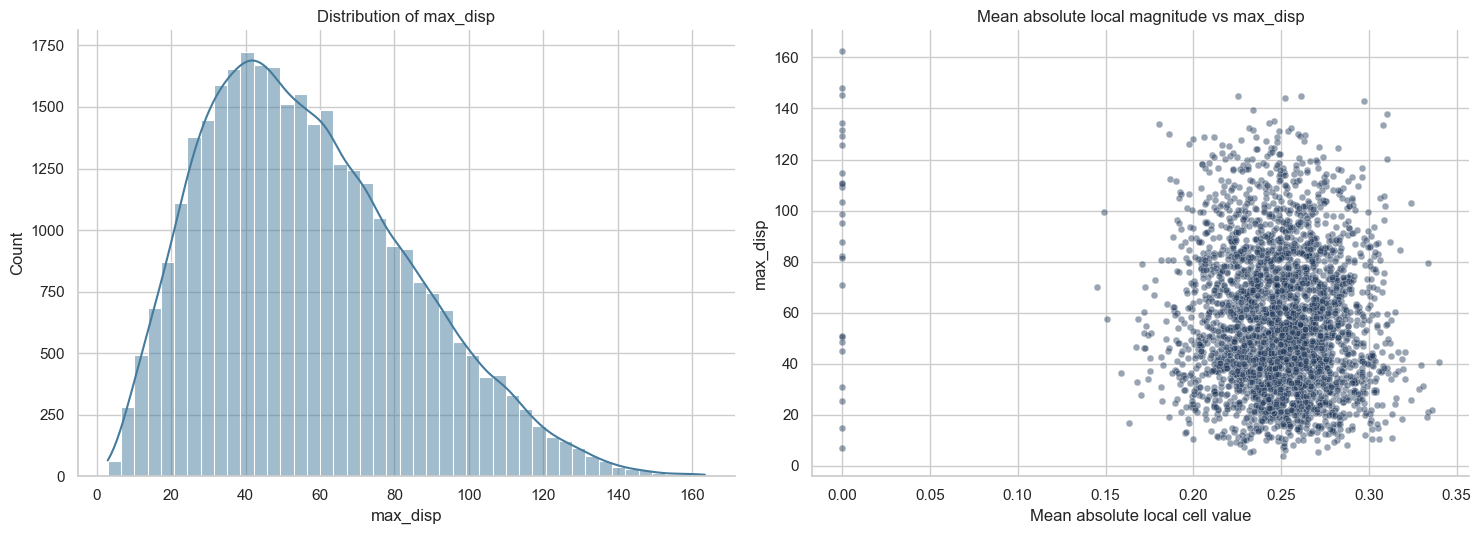

In [4]:
local_abs_mean = df[local_cols].abs().mean(axis=1)
scatter_df = df.sample(min(3000, len(df)), random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(df["max_disp"], bins=45, kde=True, color="#457b9d", ax=axes[0])
axes[0].set_title("Distribution of max_disp")
axes[0].set_xlabel("max_disp")

sns.scatterplot(
    x=local_abs_mean.loc[scatter_df.index],
    y=scatter_df["max_disp"],
    alpha=0.45,
    s=24,
    color="#1d3557",
    ax=axes[1],
)
axes[1].set_title("Mean absolute local magnitude vs max_disp")
axes[1].set_xlabel("Mean absolute local cell value")
axes[1].set_ylabel("max_disp")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()


### PCA + t-SNE Projection (Structure in Local Modification Space)

Here the local grid is flattened only for the dimensionality-reduction algorithms, not because we want to forget the grid structure. PCA gives a linear summary of how much variation the leading directions explain. t-SNE focuses more on local neighborhoods and can reveal whether the local modifications form clusters, smooth transitions, or overlapping regions in feature space.

Treat these plots as geometric sanity checks rather than performance metrics. If you see clear structure, that is evidence that the cVAE will have a meaningful manifold to learn. If the point cloud looks extremely diffuse, that does not prove failure, but it does suggest that generation may be more challenging and that conditioning will matter a lot.

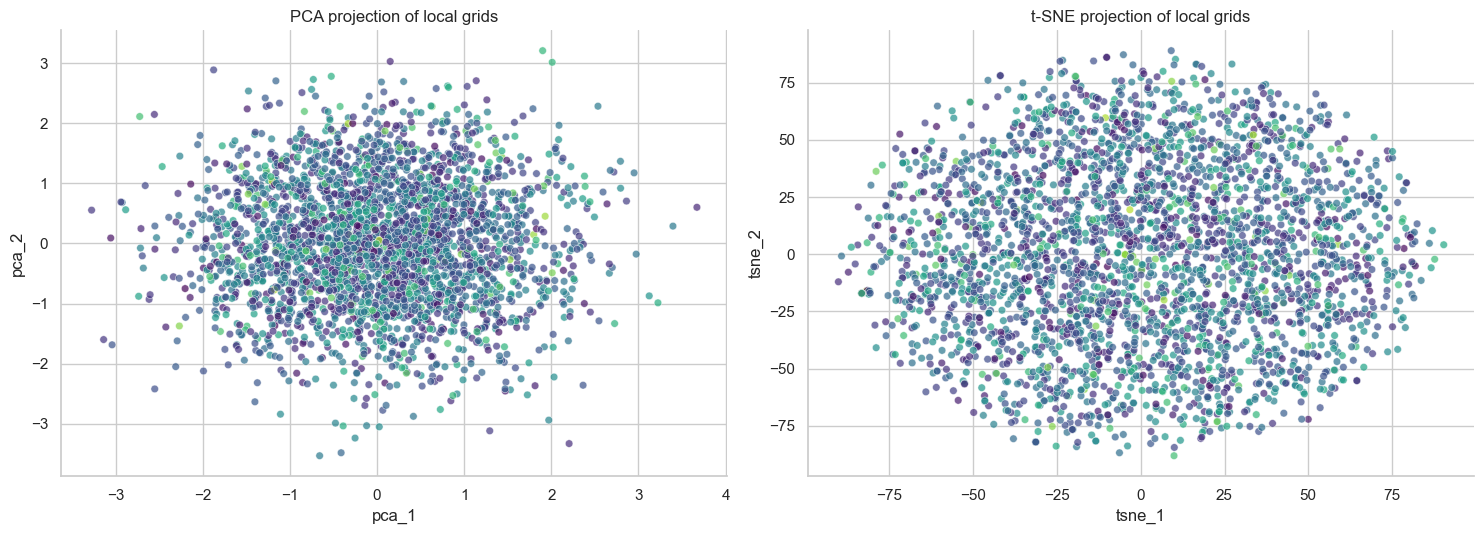

In [5]:
local_for_eda = StandardScaler().fit_transform(df[local_cols].astype("float32"))
pca = PCA(n_components=2, random_state=SEED)
local_pca = pca.fit_transform(local_for_eda)

tsne_input = PCA(n_components=min(20, local_for_eda.shape[1]), random_state=SEED).fit_transform(local_for_eda)
tsne = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=SEED, perplexity=min(30, max(5, len(df) // 200)))
local_tsne = tsne.fit_transform(tsne_input)

projection_df = pd.DataFrame({
    "pca_1": local_pca[:, 0],
    "pca_2": local_pca[:, 1],
    "tsne_1": local_tsne[:, 0],
    "tsne_2": local_tsne[:, 1],
    "max_disp": df["max_disp"].to_numpy(),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(data=projection_df.sample(min(3000, len(projection_df)), random_state=SEED), x="pca_1", y="pca_2", hue="max_disp", palette="viridis", alpha=0.7, s=30, ax=axes[0], legend=False)
axes[0].set_title("PCA projection of local grids")

sns.scatterplot(data=projection_df.sample(min(3000, len(projection_df)), random_state=SEED), x="tsne_1", y="tsne_2", hue="max_disp", palette="viridis", alpha=0.7, s=30, ax=axes[1], legend=False)
axes[1].set_title("t-SNE projection of local grids")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()


## 5. Train/Validation/Test Split

We split before any learned preprocessing so the validation and test sets stay truly unseen. This is the same leakage-avoidance habit used throughout the teaching notebooks. Validation is for model development, early stopping, and sanity checks. Test is reserved for the final evaluation only after the modeling choices are already fixed.

For a more research-oriented workflow, you may eventually want to split by `global_family_id` instead of by random rows so closely related variants from one family do not leak across splits. For this introductory notebook we keep the split random but reproducible so the pipeline stays simple and easy to compare across runs.

In [6]:
X_local_raw = df[local_cols].astype("float32").copy()
C_raw = df[condition_cols].astype("float32").copy()
idx_all = df["sample_id"].copy()

X_train_raw, X_temp_raw, C_train_raw, C_temp_raw, idx_train, idx_temp = train_test_split(
    X_local_raw,
    C_raw,
    idx_all,
    test_size=0.30,
    random_state=SEED,
)

X_val_raw, X_test_raw, C_val_raw, C_test_raw, idx_val, idx_test = train_test_split(
    X_temp_raw,
    C_temp_raw,
    idx_temp,
    test_size=0.50,
    random_state=SEED,
)

print(f"Train rows: {len(X_train_raw):,}")
print(f"Validation rows: {len(X_val_raw):,}")
print(f"Test rows: {len(X_test_raw):,}")


Train rows: 22,937
Validation rows: 4,915
Test rows: 4,916


## 6. Leakage-Safe Preprocessing (Condition + Local Standardization)

The cVAE sees two different numeric spaces: the local modification vector that must be reconstructed, and the condition vector that tells the model what kind of sample to generate. We standardize both, but we fit those scalers on the training split only. That preserves a clean separation between training knowledge and the unseen validation/test data.

This step matters for two reasons. First, it makes optimization much more stable because large-scale features do not dominate smaller-scale ones. Second, it gives the encoder and decoder a consistent numeric range, which makes reconstruction and latent sampling easier to interpret. Later, any generated local grids are inverse-transformed back into the original design units.

In [7]:
local_scaler = StandardScaler()
condition_scaler = StandardScaler()

X_train = local_scaler.fit_transform(X_train_raw).astype("float32")
X_val = local_scaler.transform(X_val_raw).astype("float32")
X_test = local_scaler.transform(X_test_raw).astype("float32")

C_train = condition_scaler.fit_transform(C_train_raw).astype("float32")
C_val = condition_scaler.transform(C_val_raw).astype("float32")
C_test = condition_scaler.transform(C_test_raw).astype("float32")

print(f"X_train shape: {X_train.shape}")
print(f"C_train shape: {C_train.shape}")
print(f"Scaled local mean (train): {X_train.mean():.4f}")
print(f"Scaled condition mean (train): {C_train.mean():.4f}")


X_train shape: (22937, 25)
C_train shape: (22937, 5)
Scaled local mean (train): -0.0000
Scaled condition mean (train): -0.0000


## 7. Conditional Variational Autoencoder (MLP cVAE)

This is the modeling core of the notebook. The next code cell begins with the experiment knobs that belong specifically to the model and training loop: latent dimensionality, KL-loss weight `beta`, hidden-layer widths, learning rate, epoch budget, batch size, and early stopping patience. That is the same organizational idea used in the simpler regression and classification notebooks: dataset choices stay in the load section, while model choices stay beside the model.

A conditional VAE is a natural fit for inverse design because one desired performance target can correspond to many valid local grids. The condition vector tells the network what family/response context to satisfy, while the latent vector captures the remaining design freedom. To keep the implementation lean, almost everything uses built-in Keras pieces: Functional API submodels for the encoder and decoder, standard `Dense` layers, Adam, `EarlyStopping`, and `ReduceLROnPlateau`. The only custom logic is the small sampling layer and the thin `keras.Model` wrapper that computes reconstruction and KL losses.

If you ever see a TensorFlow message mentioning `tf.placeholder`, that trace comes from TensorFlow/Keras backend internals while the custom training graph is being built. It is not caused by an explicit deprecated placeholder call in this notebook, and setting the TensorFlow logger to `ERROR` keeps that low-level noise out of the teaching flow.

### Implementation Notes + References

The encoder and decoder are built with the Keras Functional API because they are genuine submodels we want to save and reuse later. The outer cVAE uses model subclassing only so we can define the VAE-style loss cleanly and track total, reconstruction, and KL terms as separate metrics during `fit`.

References for model mechanics: [Keras Functional API](https://keras.io/guides/functional_api/), [Keras Model subclassing](https://keras.io/guides/making_new_layers_and_models_via_subclassing/), [Keras Variational AutoEncoder example](https://keras.io/examples/generative/vae/), [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/), [Keras ReduceLROnPlateau](https://keras.io/api/callbacks/reduce_lr_on_plateau/).

In [8]:
class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon
def make_dense_stack(hidden_units, prefix):
    return keras.Sequential(
        [
            keras.layers.Dense(units, activation="relu", name=f"{prefix}_dense_{idx}")
            for idx, units in enumerate(hidden_units, start=1)
        ],
        name=f"{prefix}_stack",
    )
def build_mlp_encoder(n_local, n_condition, latent_dim, hidden_units):
    x_input = keras.Input(shape=(n_local,), name="x_input")
    c_input = keras.Input(shape=(n_condition,), name="c_input")
    stack = make_dense_stack(hidden_units, prefix="encoder")
    x = keras.layers.Concatenate(name="encoder_concat")([x_input, c_input])
    x = stack(x)
    z_mean = keras.layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])
    return keras.Model([x_input, c_input], [z_mean, z_log_var, z], name="mlp_cvae_encoder")
def build_mlp_decoder(n_local, n_condition, latent_dim, hidden_units):
    z_input = keras.Input(shape=(latent_dim,), name="z_input")
    c_input = keras.Input(shape=(n_condition,), name="c_input")
    stack = make_dense_stack(hidden_units, prefix="decoder")
    x = keras.layers.Concatenate(name="decoder_concat")([z_input, c_input])
    x = stack(x)
    x_output = keras.layers.Dense(n_local, name="x_output")(x)
    return keras.Model([z_input, c_input], x_output, name="mlp_cvae_decoder")
class ConditionalVAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]
    def _unpack_inputs(self, data):
        if isinstance(data, tuple):
            if len(data) == 2 and isinstance(data[0], (tuple, list)):
                x, c = data[0]
                return x, c
            if len(data) == 2 and not isinstance(data[0], (tuple, list)):
                x, c = data
                return x, c
            if len(data) == 1 and isinstance(data[0], (tuple, list)):
                x, c = data[0]
                return x, c
        raise ValueError(f"Unexpected data structure passed to the cVAE: {type(data)}")
    def _compute_losses(self, x, c, training):
        z_mean, z_log_var, z = self.encoder([x, c], training=training)
        reconstruction = self.decoder([z, c], training=training)
        reconstruction_loss = keras.ops.mean(keras.ops.sum(keras.ops.square(x - reconstruction), axis=1))
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var), axis=1)
        )
        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss
    def train_step(self, data):
        x, c = self._unpack_inputs(data)
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(x, c, training=True)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {metric.name: metric.result() for metric in self.metrics}
    def test_step(self, data):
        x, c = self._unpack_inputs(data)
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(x, c, training=False)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {metric.name: metric.result() for metric in self.metrics}
    def call(self, inputs, training=False):
        x, c = inputs
        z_mean, z_log_var, z = self.encoder([x, c], training=training)
        reconstruction = self.decoder([z, c], training=training)
        return reconstruction

In [9]:
LATENT_DIM = 16
BETA = 0.01
MLP_HIDDEN_UNITS = (64, 64)
LEARNING_RATE = 4e-3
EPOCHS = 4096
BATCH_SIZE = 256
EARLY_STOPPING_PATIENCE = 64

print(
    "Model config -> "
    f"LATENT_DIM={LATENT_DIM}, BETA={BETA}, HIDDEN_UNITS={MLP_HIDDEN_UNITS}, "
    f"LEARNING_RATE={LEARNING_RATE}, EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, "
    f"EARLY_STOPPING_PATIENCE={EARLY_STOPPING_PATIENCE}"
)

encoder = build_mlp_encoder(X_train.shape[1], C_train.shape[1], LATENT_DIM, MLP_HIDDEN_UNITS)
decoder = build_mlp_decoder(X_train.shape[1], C_train.shape[1], LATENT_DIM, MLP_HIDDEN_UNITS)

model = ConditionalVAE(encoder, decoder, beta=BETA, name="mlp_cvae")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

early_stop_patience = EARLY_STOPPING_PATIENCE
reduce_lr_patience = max(1, early_stop_patience // 2)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=early_stop_patience,
    restore_best_weights=True,
    min_delta=1e-3,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=reduce_lr_patience,
    min_lr=1e-6,
    verbose=1,
)

history = model.fit(
    x=(X_train, C_train),
    validation_data=(X_val, C_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stopping, reduce_lr],
)

print(f"Training finished after {len(history.history['loss'])} epochs.")

Model config -> LATENT_DIM=16, BETA=0.01, HIDDEN_UNITS=(64, 64), LEARNING_RATE=0.004, EPOCHS=4096, BATCH_SIZE=256, EARLY_STOPPING_PATIENCE=64
Epoch 1/4096
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 16.8596 - loss: 23.7923 - reconstruction_loss: 23.6237 - val_kl_loss: 55.6566 - val_loss: 13.8065 - val_reconstruction_loss: 13.2499 - learning_rate: 0.0040
Epoch 2/4096
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - kl_loss: 57.5487 - loss: 12.3179 - reconstruction_loss: 11.7425 - val_kl_loss: 54.6571 - val_loss: 10.4140 - val_reconstruction_loss: 9.8674 - learning_rate: 0.0040
Epoch 3/4096
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - kl_loss: 53.4960 - loss: 10.1149 - reconstruction_loss: 9.5800 - val_kl_loss: 50.2801 - val_loss: 9.9503 - val_reconstruction_loss: 9.4475 - learning_rate: 0.0040
Epoch 4/4096
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - kl_loss: 49.9921 - loss: 9.8108 - reconstruction_loss: 9.3109 - val_kl_loss: 48.8873 - val_loss: 9.7929 - val_reconstruction_loss: 9.3041 - learning

## 8. Training Curves

Generative models have more than one loss term, so a single scalar loss plot is not enough. The total loss tells you what the optimizer is minimizing, the reconstruction term tells you how well the decoder rebuilds local grids, and the KL term tells you how strongly the latent distribution is being regularized toward the prior.

When reading these curves, focus on trend shape rather than one noisy epoch. If reconstruction improves while validation worsens, you are likely overfitting. If KL collapses to nearly zero immediately, the latent space may not be contributing much. If KL dominates too strongly, the decoder may struggle to preserve meaningful local-grid detail. Because this notebook now uses `ReduceLROnPlateau`, the markers also show where the optimizer stepped down the learning rate after validation loss stopped improving.

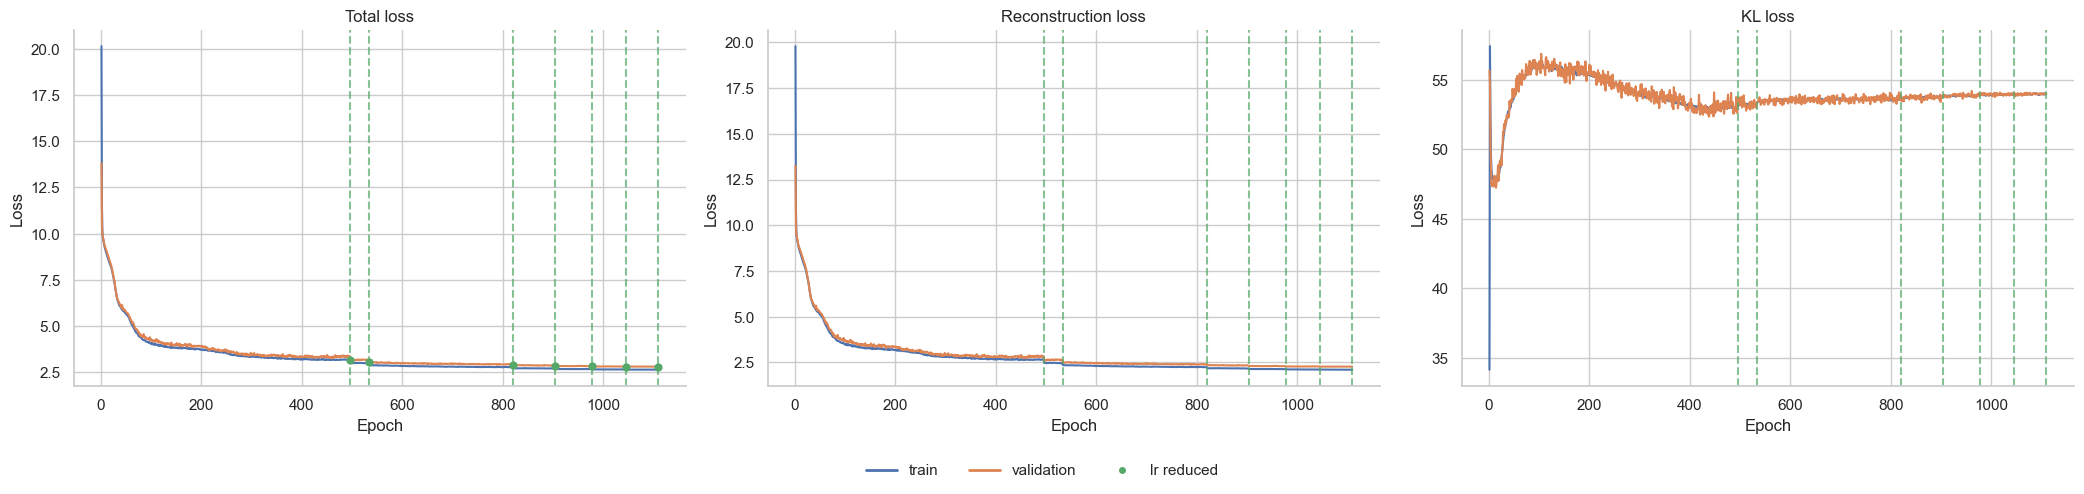

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes = axes.ravel()

history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)

lr_drop_epochs = []
if "learning_rate" in history_df.columns:
    lr_drop_epochs = history_df.loc[
        history_df["learning_rate"].diff().fillna(0) < 0,
        "epoch",
    ].tolist()

sns.lineplot(data=history_df, x="epoch", y="loss", ax=axes[0], label="train_loss")
sns.lineplot(data=history_df, x="epoch", y="val_loss", ax=axes[0], label="val_loss")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=history_df, x="epoch", y="reconstruction_loss", ax=axes[1], label="train_reconstruction")
sns.lineplot(data=history_df, x="epoch", y="val_reconstruction_loss", ax=axes[1], label="val_reconstruction")
axes[1].set_title("Reconstruction loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

sns.lineplot(data=history_df, x="epoch", y="kl_loss", ax=axes[2], label="train_kl")
sns.lineplot(data=history_df, x="epoch", y="val_kl_loss", ax=axes[2], label="val_kl")
axes[2].set_title("KL loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")

for ax in axes:
    for epoch in lr_drop_epochs:
        ax.axvline(epoch, color=sns.color_palette()[2], linestyle="--", alpha=0.7, linewidth=1.5)

lr_handle = None
if lr_drop_epochs:
    drop_mask = history_df["epoch"].isin(lr_drop_epochs)
    lr_handle = axes[0].scatter(
        history_df.loc[drop_mask, "epoch"],
        history_df.loc[drop_mask, "val_loss"],
        color=sns.color_palette()[2],
        s=24,
        zorder=5,
        label="lr reduced",
    )

for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

handles = [
    plt.Line2D([0], [0], color=sns.color_palette()[0], lw=2, label="train"),
    plt.Line2D([0], [0], color=sns.color_palette()[1], lw=2, label="validation"),
]
if lr_handle is not None:
    handles.append(
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=sns.color_palette()[2],
            markersize=6,
            label="lr reduced",
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=len(handles),
    frameon=False,
    bbox_to_anchor=(0.5, 0),
)

sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 9. Final Evaluation on the Test Set

Only now do we touch the test split. This is the final, unbiased checkpoint after the architectural choices and training settings are already fixed. A cVAE is not judged exactly like a forward regressor, so this section uses two complementary checks: reconstruction quality on held-out samples, and conditional generation sanity under fixed conditions.

The reconstruction metrics are reported back in the original local-parameter units after inverse-transforming the scaler. That makes the error easier to interpret physically. The heatmaps then let you compare whether the broad spatial pattern of each local grid survives encoding and decoding. Finally, random latent draws under fixed conditions let you inspect whether the decoder can generate plausible alternative local grids rather than simply memorizing one template.

Test reconstruction MAE:  0.0573
Test reconstruction RMSE: 0.0864


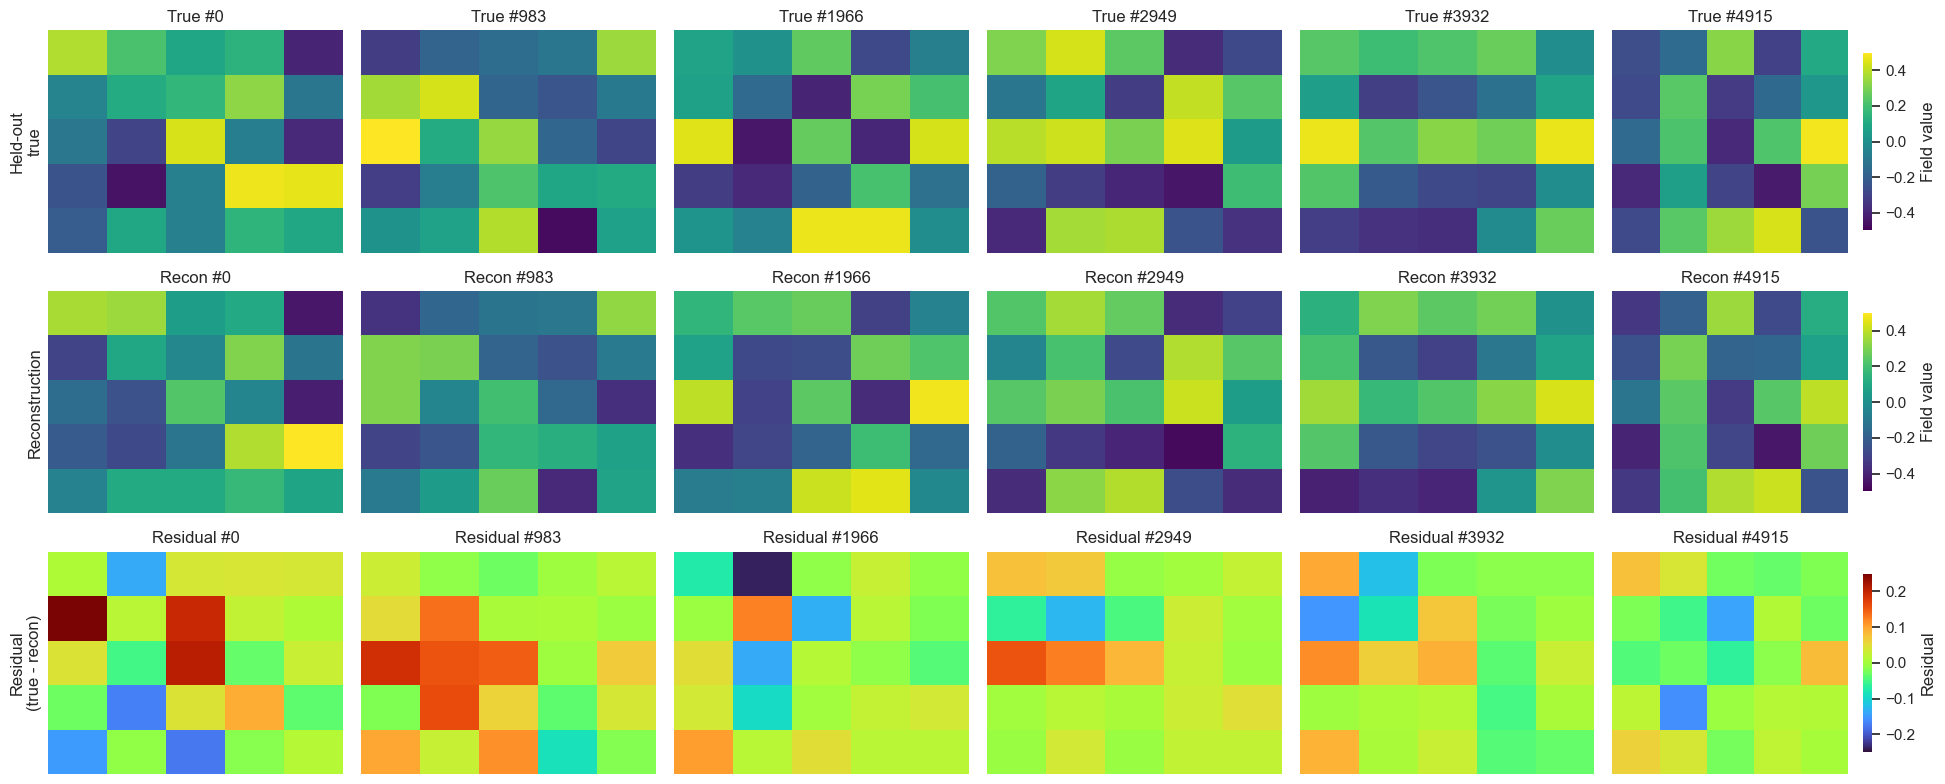

In [11]:
z_mean_test, z_log_var_test, z_test = encoder.predict([X_test, C_test], verbose=0)
X_test_recon_scaled = decoder.predict([z_test, C_test], verbose=0)

X_test_true = local_scaler.inverse_transform(X_test)
X_test_recon = local_scaler.inverse_transform(X_test_recon_scaled)
X_test_residual = X_test_true - X_test_recon  # positive => recon is too low

recon_mae = mean_absolute_error(X_test_true.reshape(-1), X_test_recon.reshape(-1))
recon_rmse = root_mean_squared_error(X_test_true.reshape(-1), X_test_recon.reshape(-1))
print(f"Test reconstruction MAE:  {recon_mae:.4f}")
print(f"Test reconstruction RMSE: {recon_rmse:.4f}")

sample_count = min(6, len(X_test_recon))
sample_positions = np.linspace(0, len(X_test_recon) - 1, sample_count, dtype=int)

sample_true = X_test_true[sample_positions]
sample_recon = X_test_recon[sample_positions]
sample_resid = X_test_residual[sample_positions]

field_lim = np.max(np.abs(np.concatenate([sample_true, sample_recon], axis=0)))
resid_lim = np.max(np.abs(sample_resid))
field_lim = max(field_lim, 1e-8)
resid_lim = max(resid_lim, 1e-8)

fig, axes = plt.subplots(3, sample_count, figsize=(3.3 * sample_count, 8.0))
if sample_count == 1:
    axes = np.array(axes).reshape(3, 1)

for col, idx in enumerate(sample_positions):
    true_grid = X_test_true[idx].reshape(grid_n, grid_n)
    recon_grid = X_test_recon[idx].reshape(grid_n, grid_n)
    resid_grid = X_test_residual[idx].reshape(grid_n, grid_n)

    show_cbar = (col == sample_count - 1)

    sns.heatmap(
        true_grid,
        cmap="viridis",
        center=0.0,
        vmin=-field_lim,
        vmax=field_lim,
        cbar=show_cbar,
        cbar_kws={"shrink": 0.8, "label": "Field value"} if show_cbar else None,
        ax=axes[0, col],
    )
    axes[0, col].set_title(f"True #{idx}")
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])

    sns.heatmap(
        recon_grid,
        cmap="viridis",
        center=0.0,
        vmin=-field_lim,
        vmax=field_lim,
        cbar=show_cbar,
        cbar_kws={"shrink": 0.8, "label": "Field value"} if show_cbar else None,
        ax=axes[1, col],
    )
    axes[1, col].set_title(f"Recon #{idx}")
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])

    sns.heatmap(
        resid_grid,
        cmap="turbo",
        center=0.0,
        vmin=-resid_lim,
        vmax=resid_lim,
        cbar=show_cbar,
        cbar_kws={"shrink": 0.8, "label": "Residual"} if show_cbar else None,
        ax=axes[2, col],
    )
    axes[2, col].set_title(f"Residual #{idx}")
    axes[2, col].set_xticks([])
    axes[2, col].set_yticks([])

axes[0, 0].set_ylabel("Held-out\ntrue")
axes[1, 0].set_ylabel("Reconstruction")
axes[2, 0].set_ylabel("Residual\n(true - recon)")

plt.tight_layout()
plt.show()

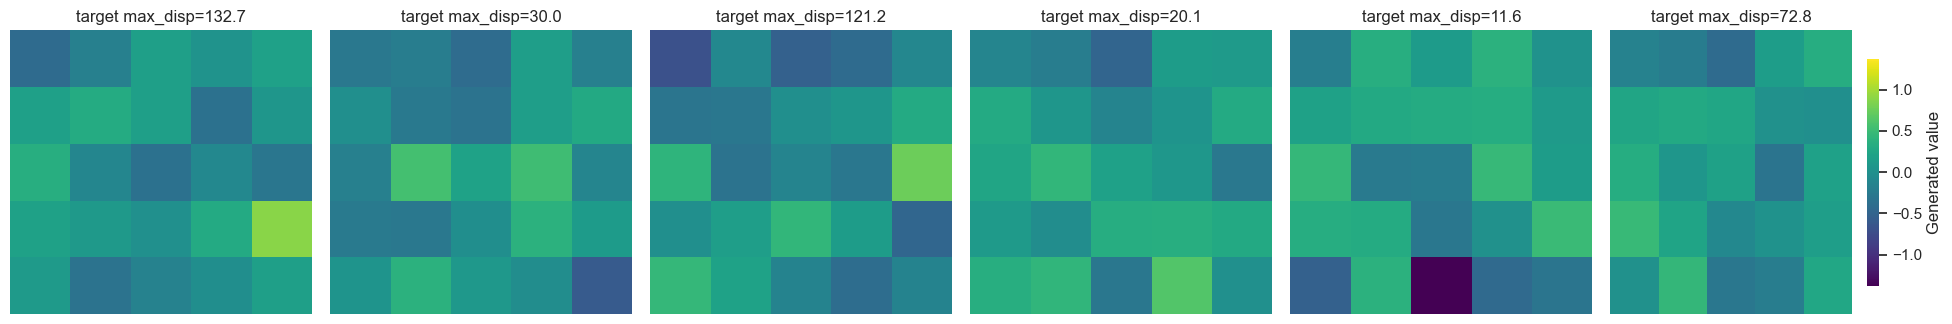

In [12]:
condition_positions = np.linspace(0, len(C_test) - 1, sample_count, dtype=int)
z_random = np.random.normal(size=(sample_count, LATENT_DIM)).astype("float32")
condition_batch = C_test[condition_positions]

generated_scaled = decoder.predict([z_random, condition_batch], verbose=0)
generated = local_scaler.inverse_transform(generated_scaled)
condition_original = condition_scaler.inverse_transform(condition_batch)
target_idx = condition_cols.index(target_col)

gen_lim = np.max(np.abs(generated))
gen_lim = max(gen_lim, 1e-8)

fig, axes = plt.subplots(1, sample_count, figsize=(3.3 * sample_count, 3.4))
if sample_count == 1:
    axes = [axes]

for i, (ax, grid_vals, cond_vals) in enumerate(zip(axes, generated, condition_original)):
    show_cbar = (i == sample_count - 1)
    sns.heatmap(
        grid_vals.reshape(grid_n, grid_n),
        cmap="viridis",
        center=0.0,
        vmin=-gen_lim,
        vmax=gen_lim,
        cbar=show_cbar,
        cbar_kws={"shrink": 0.8, "label": "Generated value"} if show_cbar else None,
        ax=ax,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"target {target_col}={cond_vals[target_idx]:.1f}")

plt.tight_layout()
plt.show()

## 10. Save Trained Artifacts

For a custom generative workflow, the cleanest teaching artifact is usually not one monolithic training object. Instead, we save the **encoder**, the **decoder**, and the fitted preprocessing objects separately. That keeps later inference notebooks simpler because generation only needs the decoder and the scalers, while latent analysis may also need the encoder.

The metadata JSON records the dataset path, local-grid layout, condition columns, and the most important model/training settings. Saving those choices alongside the weights makes later reuse much less error-prone, especially once you start comparing multiple inverse-design runs.

In [13]:
if Path("inclass_examples").exists():
    artifacts_dir = Path("inclass_examples/artifacts/cvae_mlp_globalLocalFamily")
else:
    artifacts_dir = Path("../artifacts/cvae_mlp_globalLocalFamily")
artifacts_dir.mkdir(parents=True, exist_ok=True)

encoder_path = artifacts_dir / "globalLocalFamily_cvae_mlp_encoder.keras"
decoder_path = artifacts_dir / "globalLocalFamily_cvae_mlp_decoder.keras"
local_scaler_path = artifacts_dir / "globalLocalFamily_cvae_mlp_local_scaler.pkl"
condition_scaler_path = artifacts_dir / "globalLocalFamily_cvae_mlp_condition_scaler.pkl"
metadata_path = artifacts_dir / "globalLocalFamily_cvae_mlp_metadata.json"

encoder.save(encoder_path)
decoder.save(decoder_path)
with open(local_scaler_path, "wb") as f:
    pickle.dump(local_scaler, f)
with open(condition_scaler_path, "wb") as f:
    pickle.dump(condition_scaler, f)

metadata = {
    "source_csv": str(CSV_PATH),
    "target_col": target_col,
    "condition_cols": condition_cols,
    "local_cols": local_cols,
    "local_grid_n": int(grid_n),
    "local_grid_order": "row_major",
    "latent_dim": LATENT_DIM,
    "beta": BETA,
    "hidden_units": list(MLP_HIDDEN_UNITS),
    "learning_rate": LEARNING_RATE,
    "epochs_requested": EPOCHS,
    "batch_size": BATCH_SIZE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "seed": SEED,
    "test_metrics": {
        "reconstruction_mae": float(recon_mae),
        "reconstruction_rmse": float(recon_rmse),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved encoder to: {encoder_path.resolve()}")
print(f"Saved decoder to: {decoder_path.resolve()}")
print(f"Saved metadata to: {metadata_path.resolve()}")

Saved encoder to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\cvae_mlp_globalLocalFamily\globalLocalFamily_cvae_mlp_encoder.keras
Saved decoder to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\cvae_mlp_globalLocalFamily\globalLocalFamily_cvae_mlp_decoder.keras
Saved metadata to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\cvae_mlp_globalLocalFamily\globalLocalFamily_cvae_mlp_metadata.json


## 11. Mini Exercises

These exercises are meant to turn the notebook from a fixed recipe into an experiment sandbox. Each one changes one modeling assumption at a time so you can connect cause and effect instead of changing many knobs at once. When you try them, keep notes on how reconstruction quality, latent behavior, and generation diversity change together.

1. Train the same cVAE with `LATENT_DIM = 2`, `4`, and `8`, then compare reconstruction quality and generation diversity. Explain how shrinking or expanding the latent bottleneck changes what the model can remember.
2. Remove `max_disp_baseline` from the condition vector and compare the generated local grids against the baseline-aware version. Does the model lose useful family context, or is the extra condition mostly redundant?
3. Split by `global_family_id` instead of random rows and compare whether held-out reconstruction becomes harder. This is a good first step toward a more honest family-generalization benchmark.
4. Train the CNN/grid cVAE notebook on the same dataset and compare whether preserving neighborhood structure helps more than the lightweight flattened MLP representation.